In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
import os
os.chdir("/home/piai/Desktop/git/1 Big Data 분석 기초")
# 폰트
matplotlib.rc('font', family = "NanumSquare")
#음수
matplotlib.rc('axes', unicode_minus=False)

## 실습1(정규분포)

In [2]:
mu = 175
sigma = 5v
x = 180

prob = stats.norm.cdf(x,mu,sigma)
print("키가 {0}인 사람은 상위 {1:.2f}% 입니다.".format(x, (1-prob)*100))

키가 180인 사람은 상위 15.87% 입니다.


## 실습2(정규분포)

In [3]:
mu = 12
sigma = 3
x1 = 9
x2 = 15

prob1 = stats.norm.cdf(x1, mu, sigma)
prob2 = stats.norm.cdf(x2, mu, sigma)
print("자동차가 {0}km 이상, {1}km 이하를 달릴 확률은 {2:.2f}% 입니다.".format(x1,x2,(prob2-prob1)*100))
print("자동차가 {0}km 이상을 달릴 확률은 {1:.2f}% 입니다.".format(x2,(1-prob2)*100))

자동차가 9km 이상, 15km 이하를 달릴 확률은 68.27% 입니다.
자동차가 15km 이상을 달릴 확률은 15.87% 입니다.


## 실습3(t분포)

In [4]:
t = 2.0
df = 100

prob = stats.t.cdf(t, df)
print("t값이 {0}일때, P(T<=t)는 {1:.3f}입니다.".format(t,prob))

t값이 2.0일때, P(T<=t)는 0.976입니다.


## 실습4(카이제곱분포)

In [5]:
chisq = 3.0
df = 8

prob = stats.chi2.cdf(chisq, df)
print("P(X<={0})의 값은 {1:.3f}입니다.".format(chisq, prob))

P(X<=3.0)의 값은 0.066입니다.


## 실습5(F분포)

In [6]:
f = 1.5
dfnum = 10
dfden = 100

prob = stats.f.cdf(x=f, dfn = dfnum, dfd = dfden)
print("F값이 {0}일때, P(X<=F)의 값은 {1:.3f}입니다.".format(f,prob))

F값이 1.5일때, P(X<=F)의 값은 0.850입니다.


## 실습6(이항분포)

In [7]:
n = 5

for i in range(n+1):
    prob = stats.binom.pmf(k=i, n=n, p =0.3)
    print("불량대수가 {0}대일 확률은 {1:.2f}% 입니다".format(i, prob*100))

불량대수가 0대일 확률은 16.81% 입니다
불량대수가 1대일 확률은 36.01% 입니다
불량대수가 2대일 확률은 30.87% 입니다
불량대수가 3대일 확률은 13.23% 입니다
불량대수가 4대일 확률은 2.83% 입니다
불량대수가 5대일 확률은 0.24% 입니다


In [54]:
n = 5
prob = stats.binom.cdf(1, 5, p =0.05)
print(100 -(prob*100))


2.2592500000000086


5대의 차량 중 불량대수가 1대가 나올 확률이 36%로 가장 높다.

## 실습7(정규성 검정)

In [9]:
df = pd.read_csv("2sample_t_test.csv")
df.head()

,Mat_A,Mat_B
0,73.4,68.7
1,77.0,71.4
2,73.7,69.8
3,73.3,75.3
4,73.1,71.3


1. 가설검정(2개의 가설검정이 동일하여 한번에 기입하였습니다.)<br>
    귀무가설 - Mat_A와 Mat_B는 정규성을 따른다.<br>
    대립가설 - Mat_A와 Mat_B는 정규성을 따르지 않는다.<br>
2. 신뢰수준 95%, 유의수준 5%

In [10]:
statistic1, p1 = stats.shapiro(df['Mat_A'])
statistic2, p2 = stats.shapiro(df['Mat_B'])

print("Shapiro-Wilk Test결과 Mat_A의 검정통계량은 {:.3f}, p-value는 {:.3f}입니다.".format(statistic1, p1 ))
print("Shapiro-Wilk Test결과 Mat_B의 검정통계량은 {:.3f}, p-value는 {:.3f}입니다.".format(statistic2, p2 ))

Shapiro-Wilk Test결과 Mat_A의 검정통계량은 0.906, p-value는 0.256입니다.
Shapiro-Wilk Test결과 Mat_B의 검정통계량은 0.973, p-value는 0.917입니다.


Mat_A의 p-value 0.256은 0.05보다 크므로 귀무가설을 기각하지 못한다.<br>
Mat_B의 p-value 0.917은 0.05보다 크므로 귀무가설을 기각하지 못한다.

결론:
Mat_A와 Mat_B는 모두 정규성을 따른다.

## 실습8(모평균 구간추정)

In [11]:
df = pd.DataFrame({"sample" : [18, 18, 20, 21, 20, 23, 19, 18, 17, 21, 22, 20, 20, 21, 20, 19, 19, 18, 17, 19]})
df.head()

,sample
0,18
1,18
2,20
3,21
4,20


1. 가설검정<br>
    귀무가설 - 데이터는 정규성을 따른다.<br>
    대립가설 - 데이터는 정규성을 따르지 않는다.<br>
2. 신뢰수준 95%, 유의수준 5%

In [12]:
statistic, p = stats.shapiro(df)

print("Shapiro-Wilk Test결과 데이터의 검정통계량은 {:.3f}, p-value는 {:.3f}입니다.".format(statistic, p ))

Shapiro-Wilk Test결과 데이터의 검정통계량은 0.956, p-value는 0.461입니다.


데이터의 p-value 0.461은 0.05보다 크므로 귀무가설을 기각하지 못한다.<br>

결론:
데이터는 정규성을 따른다.

In [13]:
lower, upper = stats.norm.interval(0.95, loc = df.mean(), scale = 3.8/np.sqrt(20))
print("새로운 감자 품종의 95%의 값에 대한 신뢰구간은 {0}<=μ<={1} 입니다.".format(lower[0].round(2), upper[0].round(2)))

새로운 감자 품종의 95%의 값에 대한 신뢰구간은 17.83<=μ<=21.17 입니다.


## 실습9(모평균 구간추정)

In [14]:
df = pd.DataFrame({'sample': [73, 71, 74, 69, 70, 73, 70, 68, 75, 72, 70, 72, 73, 70, 70, 72, 71, 70, 75, 72]})
df.head()                

,sample
0,73
1,71
2,74
3,69
4,70


1. 가설검정<br>
    귀무가설 - 데이터는 정규성을 따른다.<br>
    대립가설 - 데이터는 정규성을 따르지 않는다.<br>
2. 신뢰수준 95%, 유의수준 5%

In [15]:
statistic, p = stats.shapiro(df)

print("Shapiro-Wilk Test결과 데이터의 검정통계량은 {:.3f}, p-value는 {:.3f}입니다.".format(statistic, p ))

Shapiro-Wilk Test결과 데이터의 검정통계량은 0.947, p-value는 0.325입니다.


데이터의 p-value 0.325는 0.05보다 크므로 귀무가설을 기각하지 못한다.<br>

결론:
데이터는 정규성을 따른다.

In [16]:
lower, upper = stats.t.interval(0.95, len(df)-1, loc = df.mean(), scale = stats.sem(df))
print("새로 개발된 강종의 95%의 값에 대한 신뢰구간은 {0}<=μ<={1}입니다.".format(lower[0].round(2), upper[0].round(2)))

새로 개발된 강종의 95%의 값에 대한 신뢰구간은 70.6<=μ<=72.4입니다.


새로 개발된 강종은 예상했던 인장강도보다 더 높은 강도를 가지고 있다.

## 실습10(단일표본 t검정)

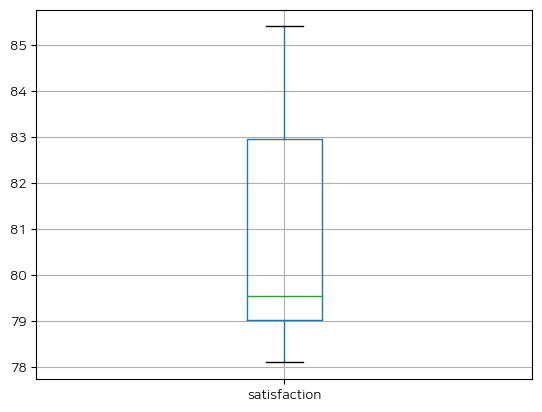

In [17]:
df = pd.DataFrame({'satisfaction': [85.0, 79.0, 79.1, 79.9, 81.6, 78.6, 85.4, 83.4, 78.1, 79.2,]})
df.boxplot()
plt.show()

### 정규성검정

1. 가설검정<br>
    귀무가설 - 만족도 데이터는 정규성을 따른다.<br>
    대립가설 - 만족도 데이터는 정규성을 따르지 않는다.<br>
2. 신뢰수준 95%, 유의수준 5%

In [18]:
statistic, p = stats.shapiro(df)
print("Shapiro-Wilk Test결과 검정통계량은 {0:.3f}, p-value는 {1:.3f}입니다.".format(statistic, p))

Shapiro-Wilk Test결과 검정통계량은 0.847, p-value는 0.054입니다.


p-value가 0.05보다 크므로 귀무가설을 기각하지 못한다.<br>
고로, 데이터는 정규성을 가진다.

### t검정

1. 가설검정<br>
    귀무가설 - 고객만족도의 평균은 개선 이전과 동일하다.<br>
    대립가설 - 고객만족도의 평균은 개선 이전과 동일하지 않다.<br>
2. 신뢰수준 95%, 유의수준 5%

In [19]:
t_results = stats.ttest_1samp(df, 78.0)
t, p = t_results.statistic[0].round(3), t_results.pvalue[0].round(3)
print("1-Sample t-test결과 검정통계량은 {}, p-value는 {}입니다.".format(t, p))

1-Sample t-test결과 검정통계량은 3.379, p-value는 0.008입니다.


p-value가 0.05보다 작으므로 귀무가설을 기각한다.<br>
결론적으로 개선활동은 고객만족도를 변화시켰다.<br>
검정통계량의 값을 고려하였을 때, 개선활동을 지속하는 것이 고객만족도 변화에 긍정적인 영향을 미칠 것이다.

## 실습11(대응표본 t검정)

In [20]:
df = pd.DataFrame({'A': [1.883, 1.715, 1.799, 1.768, 1.711, 1.832, 1.427, 1.344],
                   'B': [1.435, 1.572, 1.486, 1.511, 1.457, 1.548, 1.404, 1.800]})
df.head()

,A,B
0,1.883,1.435
1,1.715,1.572
2,1.799,1.486
3,1.768,1.511
4,1.711,1.457


In [66]:
df = pd.DataFrame({'A': [68.7, 71.4, 69.8, 75.3, 71.3, 72.7, 66.9, 70.2, 74.4, 70.1],
                   'B': [73.4, 77.0, 73.7, 73.3, 73.1, 74.5, 77.5, 76.4, 75.7, 77.1]})
df.head()

,A,B
0,68.7,73.4
1,71.4,77.0
2,69.8,73.7
3,75.3,73.3
4,71.3,73.1


In [67]:
print(stats.shapiro(df.A))
print(stats.shapiro(df.B))

ShapiroResult(statistic=0.9729753732681274, pvalue=0.9169775247573853)
ShapiroResult(statistic=0.8721038103103638, pvalue=0.10576473921537399)


In [68]:
print(stats.bartlett(df.A, df.B))

BartlettResult(statistic=1.1314628564654454, pvalue=0.28746352396763397)


In [69]:
t_result = stats.ttest_ind(df['A'],df['B'])
t,p = t_result.statistic.round(3),t_result.pvalue.round(3)
print("2-Sample t-test결과 검정통계량은 {:.3f}, p-value는 {:.3f}입니다.".format(t, p))

2-Sample t-test결과 검정통계량은 -4.186, p-value는 0.001입니다.


In [70]:
t_result = stats.ttest_ind(df['B'],df['A'])
t,p = t_result.statistic.round(3),t_result.pvalue.round(3)
print("2-Sample t-test결과 검정통계량은 {:.3f}, p-value는 {:.3f}입니다.".format(t, p))

2-Sample t-test결과 검정통계량은 4.186, p-value는 0.001입니다.


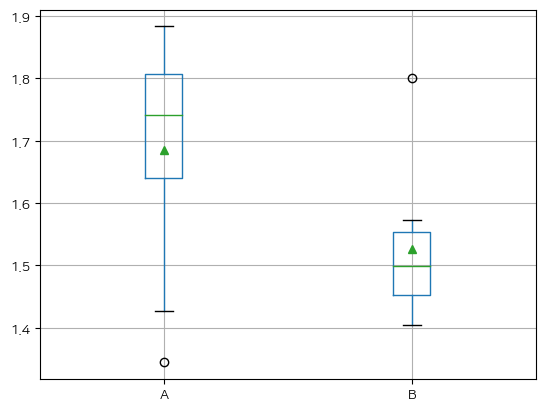

In [21]:
df.boxplot(['A','B'], showmeans = True)
plt.show()

### 정규성검정

1. 가설검정(2개의 가설검정이 동일하여 한번에 기입하였습니다.)<br>
    귀무가설 - A와 B는 정규성을 따른다.<br>
    대립가설 - A와 B는 정규성을 따르지 않는다.<br>
2. 신뢰수준 95%, 유의수준 5%

In [22]:
print(stats.shapiro(df.A))
print(stats.shapiro(df.B))

ShapiroResult(statistic=0.8425754904747009, pvalue=0.08004532009363174)
ShapiroResult(statistic=0.8393934369087219, pvalue=0.07424874603748322)


p-value가 0.05보다 크므로 귀무가설을 기각하지 못한다.<br>
고로, 데이터는 정규성을 가진다.

### 등분산검정

1. 가설검정<br>
    귀무가설 - 두 공급자의 분산은 동일하다.<br>
    대립가설 - 두 공급자의 분산은 동일하지 않다.<br>
2. 신뢰수준 95%, 유의수준 5%

In [23]:
print(stats.bartlett(df.A, df.B))

BartlettResult(statistic=1.2899966318541203, pvalue=0.25604857136527204)


p-value가 0.05보다 크므로 귀무가설을 기각하지 못한다.<br>
결론적으로 공급자 간에 분산은 동일하다.

### t검정

1. 가설검정<br>
    귀무가설 - 두 공급자의 모평균에는 차이가 없다.<br>
    귀무가설 - 두 공급자의 모평균에는 차이가 없다.<br>
2. 신뢰수준 95%, 유의수준 5%

In [24]:
t_result = stats.ttest_ind(df['A'],df['B'])
t,p = t_result.statistic.round(3),t_result.pvalue.round(3)
print("2-Sample t-test결과 검정통계량은 {:.3f}, p-value는 {:.3f}입니다.".format(t, p))

2-Sample t-test결과 검정통계량은 1.940, p-value는 0.073입니다.


p-value가 0.05보다 크므로 귀무가설을 기각하지 못한다.<br>
즉, 공급자 간에 두께의 모평균에는 차이가 없다.<br>
결론적으로 공급자간의 차이를 두지 않고 제품을 받아 사용해도 무방하다.

## 실습12(대응표본 t검정)

In [25]:
df1 = pd.DataFrame({'before': [720, 589, 780, 648, 720, 589, 780, 648, 780, 648]})
df2 = pd.DataFrame({'after': [710, 580, 787, 712, 750, 600, 782, 670, 790, 680]})
df1.head()

,before
0,720
1,589
2,780
3,648
4,720


### 정규성검정

1. 가설검정(2개의 가설검정이 동일하여 한번에 기입하였습니다.)<br>
    귀무가설 - 전후의 차이값은 정규성을 따른다.<br>
    대립가설 - 전후의 차이값은 정규성을 따르지 않는다.<br>
2. 신뢰수준 95%, 유의수준 5%

In [26]:
stats.shapiro(df1['before']-df2['after'])

ShapiroResult(statistic=0.9194085597991943, pvalue=0.3520483374595642)

p-value가 0.05보다 크므로 귀무가설을 기각하지 못한다.<br>
고로, 데이터는 정규성을 가진다.

### t검정

1. 가설검정<br>
    귀무가설 - 회사원들의 성적은 학원가기 전후 차이가 없다.<br>
    대립가설 - 회사원들의 성적은 학원가기 전후 차이가 있다.<br>
2. 신뢰수준 95%, 유의수준 5%

In [27]:
t_result = stats.ttest_rel(df1['before'], df2['after'])
t, p = t_result.statistic, t_result.pvalue
print("Paired t-test결과 검정통계량은 {:.3f}, p-value는 {:.3f}입니다.".format(t, p))

Paired t-test결과 검정통계량은 -2.266, p-value는 0.050입니다.


p-value가 0.05보다 작으므로 귀무가설을 기각한다.<br>
즉, 회사원들의 성적은 학원가기 전후 차이가 있다.<br>
Before에서 After의 차인점을 고려하였을 때, 검정통계량이 음수이므로 회사원의 성적은 증가하였다,<br>
그러므로 학원을 계속 보내는 것이 적합하다.

## 실습13(단일표본 모비율검정)

1. 가설검정<br>
    귀무가설 - 동전은 정상적인 동전과 차이가 없다.<br>
    대립가설 - 동전은 정상적인 동전과 차이가 있다.<br>
2. 신뢰수준 95%, 유의수준 5%

In [28]:
count = 40
n_obs = 100
value = 0.5

z,p = proportions_ztest(count, n_obs, value)
print("1Proportion test결과 검정통계량은 {:.3f}, p-value는 {:.3f}입니다.".format(z, p))

1Proportion test결과 검정통계량은 -2.041, p-value는 0.041입니다.


p-value가 0.05보다 작으므로 귀무가설을 기각한다.<br>
결론적으로 이 동전은 정상적인 동전과 차이가 있다.<br>
공정성을 위해서라면 동전을 바꾸는 것이 적합해보인다.

## 실습14(독립표본 모비율검정)

1. 가설검정<br>
    귀무가설 - 두 공정의 불량률은 차이가 없다.<br>
    대립가설 - 두 공정의 불량률은 차이가 있다.<br>
2. 신뢰수준 95%, 유의수준 5%

In [29]:
count = np.array([14,5])
nobs = np.array([1200,1200])
z,p = proportions_ztest(count, nobs)

print("2Proportion test결과 검정통계량은 {:.3f}, p-value는 {:.3f}입니다.".format(z, p))

2Proportion test결과 검정통계량은 2.073, p-value는 0.038입니다.


p-value가 0.05보다 작으므로 귀무가설을 기각한다.<br>
즉, 두 공정의 불량률은 차이가 있다.<br>
특히, A공정의 경우, 불량률이 매우 높아 조정이 필요해보인다.

## 실습15(카이제곱 동일성 검정)

In [30]:
df = pd.DataFrame({'A':[18,1,8,7,10,9,10], 'B':[8,2,14,5,5,9,4],
                   'C':[4,1,3,4,9,5,4], 'D':[4,1,2,3,2,7,3],
                   'E':[3,1,3,1,1,1,1], 'F':[3,25,8,10,2,1,7]})
df.head()

,A,B,C,D,E,F
0,18,8,4,4,3,3
1,1,2,1,1,1,25
2,8,14,3,2,3,8
3,7,5,4,3,1,10
4,10,5,9,2,1,2


In [56]:
df = pd.DataFrame({'A':[182,154], 'B':[213,138],
                   'C':[203,110]})
df.head()

,A,B,C
0,182,213,203
1,154,138,110


In [57]:
chi, pval, dof, expected = stats.chi2_contingency(df)

In [58]:
print("chi-square test")
print('chisq: {0:0.3f}'.format(chi))
print('p: {0:0.3f}'.format(pval))
print('degree pf freedom: {}'.format(dof))
print('expected value: \n{}'.format(expected.round(3)))

chi-square test
chisq: 7.878
p: 0.019
degree pf freedom: 2
expected value: 
[[200.928 209.898 187.174]
 [135.072 141.102 125.826]]


1. 가설검정<br>
    귀무가설 - 각 제품에 대한 이미지 차이가 없다.<br>
    대립가설 - 각 제품에 대한 이미지 차이가 있다.<br>
2. 신뢰수준 95%, 유의수준 5%

In [31]:
chi, pval, dof, expected = stats.chi2_contingency(df)

In [32]:
print("chi-square test")
print('chisq: {0:0.3f}'.format(chi))
print('p: {0:0.3f}'.format(pval))
print('degree pf freedom: {}'.format(dof))
print('expected value: \n{}'.format(expected.round(3)))

chi-square test
chisq: 98.274
p: 0.000
degree pf freedom: 30
expected value: 
[[11.004  8.21   5.24   3.843  1.921  9.782]
 [ 8.528  6.362  4.061  2.978  1.489  7.581]
 [10.454  7.799  4.978  3.651  1.825  9.293]
 [ 8.253  6.157  3.93   2.882  1.441  7.336]
 [ 7.978  5.952  3.799  2.786  1.393  7.092]
 [ 8.803  6.568  4.192  3.074  1.537  7.825]
 [ 7.978  5.952  3.799  2.786  1.393  7.092]]


p-value가 0.05보다 작으므로 귀무가설을 기각한다.<br>
각 제품별로 이미지 차이가 존재한다.<br>
결론적으로 자신의 기준에 맞는 제품을 선택하는 것이 필요하다.

## 실습16(ANOVA검정)

In [33]:
df = pd.read_csv("ANOVA.csv")
df.head()

,time,charge,gangjong,type
0,32.2,A,a,a
1,30.4,B,a,a
2,33.6,C,a,a
3,36.4,D,a,a
4,33.9,E,a,a


### 강종별 차이 분석

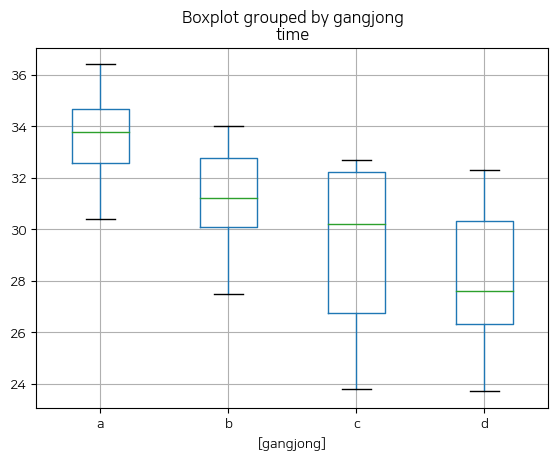

In [34]:
df.boxplot(by = 'gangjong')
plt.show()

### 정규성 검정

1. 가설검정(4개의 가설검정이 동일하여 한번에 기입하였습니다.)<br>
    귀무가설 - 'gangjong'의 유형별 데이터는 정규성을 따른다.<br>
    대립가설 - 'gangjong'의 유형별 데이터는 정규성을 따르지 않는다.<br>
2. 신뢰수준 95%, 유의수준 5%

In [35]:
# ganghong의 값별로 분리하여 정규성 검정
group = {}
for i in df['gangjong'].unique():
    group[i] = df[df['gangjong'] == i]['time']
    statistic, p = stats.shapiro(group[i])
    print("Shapiro-Wilk Test결과 {0}의 검정통계량은 {1:.3f}, p-value는 {2:.3f}입니다.".format(i,statistic, p))

Shapiro-Wilk Test결과 a의 검정통계량은 0.988, p-value는 0.984입니다.
Shapiro-Wilk Test결과 b의 검정통계량은 0.977, p-value는 0.936입니다.
Shapiro-Wilk Test결과 c의 검정통계량은 0.893, p-value는 0.334입니다.
Shapiro-Wilk Test결과 d의 검정통계량은 0.971, p-value는 0.902입니다.


4개의 결과 모드 p-value가 0.05보다 크므로, 귀무가설을 기각하지 못한다.<br>
즉, 'gangjong'의 유형별 데이터들은 모두 정규성을 따른다.

### 등분산성 검정

1. 가설검정<br>
    귀무가설 - 4개의 데이터 타입별 분산은 동일하다.<br>
    대립가설 - 4개의 데이터 타입별 분산은 동일하지 않다.<br>
2. 신뢰수준 95%, 유의수준 5%

In [36]:
statistic, p = stats.bartlett(*group.values())
print("등분산검정 결과 검정통계량은 {:.3f}, p-value는 {:.3f}입니다.".format(statistic, p))

등분산검정 결과 검정통계량은 1.873, p-value는 0.599입니다.


p-value가 0.05보다 크므로, 귀무가설을 기각하지 못한다.<br>
즉, 'gangjong'별 데이터들은 모두 등분산성을 따른다.

### ANOVA 검정

1. 가설검정<br>
    귀무가설 - gongjong유형별 정련시간은 차이가 없다.<br>
    대립가설 - gongjong유형별 정련시간은 차이가 있다.<br>
2. 신뢰수준 95%, 유의수준 5%

In [37]:
f_result = stats.f_oneway(*group.values())
f, p = f_result.statistic.round(3), f_result.pvalue.round(3)
print("One-way ANOVA 결과 F통계량은 {:.3f}, p-value는 {:.3f}입니다.".format(f,p))

One-way ANOVA 결과 F통계량은 4.172, p-value는 0.019입니다.


p-value가 0.05보다 작므로, 귀무가설을 기각한다.<br>
즉, 'gangjong'별 데이터들의 정련시간에는 차이가 있다.<br>
그러므로 짧은 정련시간을 탐색하는 사후처리가 필요하다.

### 유형별 차이 분석

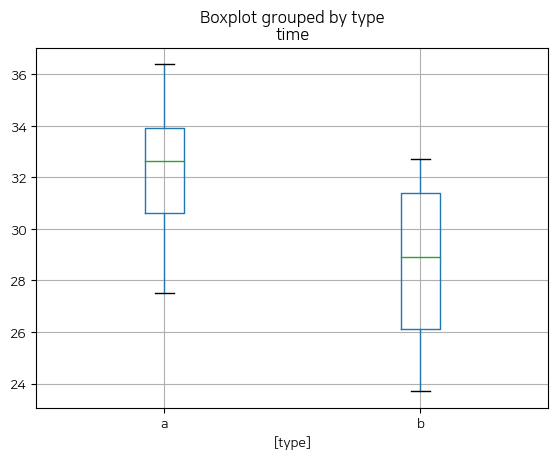

In [38]:
df.boxplot(by = 'type')
plt.show()

### 정규성검정

1. 가설검정(2개의 가설검정이 동일하여 한번에 기입하였습니다.)<br>
    귀무가설 - 'type'의 유형별 데이터는 정규성을 따른다.<br>
    대립가설 - 'type'의 유형별 데이터는 정규성을 따르지 않는다.<br>
2. 신뢰수준 95%, 유의수준 5%

In [39]:
# ganghong의 값별로 분리하여 정규성 검정
group = {}
for i in df['type'].unique():
    group[i] = df[df['type'] == i]['time']
    statistic, p = stats.shapiro(group[i])
    print("Shapiro-Wilk Test결과 {0}의 검정통계량은 {1:.3f}, p-value는 {2:.3f}입니다.".format(i,statistic, p))

Shapiro-Wilk Test결과 a의 검정통계량은 0.982, p-value는 0.991입니다.
Shapiro-Wilk Test결과 b의 검정통계량은 0.910, p-value는 0.212입니다.


4개의 결과 모드 p-value가 0.05보다 크므로, 귀무가설을 기각하지 못한다.<br>
즉, 'type'의 유형별 데이터들은 모두 정규성을 따른다.

### 등분산검정

1. 가설검정<br>
    귀무가설 - 데이터 타입별 분산은 동일하다.<br>
    대립가설 - 데이터 타입별 분산은 동일하지 않다.<br>
2. 신뢰수준 95%, 유의수준 5%

In [40]:
statistic, p = stats.bartlett(*group.values())
print("등분산검정 결과 검정통계량은 {:.3f}, p-value는 {:.3f}입니다.".format(statistic, p))

등분산검정 결과 검정통계량은 0.953, p-value는 0.329입니다.


p-value가 0.05보다 크므로, 귀무가설을 기각하지 못한다.<br>
즉, 'type'별 데이터들은 모두 등분산성을 따른다.

### ANOVA검정

1. 가설검정<br>
    귀무가설 - type유형별 정련시간은 차이가 없다.<br>
    대립가설 - type유형별 정련시간은 차이가 있다.<br>
2. 신뢰수준 95%, 유의수준 5%

In [41]:
f_result = stats.f_oneway(*group.values())
f, p = f_result.statistic.round(3), f_result.pvalue.round(3)
print("One-way ANOVA 결과 F통계량은 {:.3f}, p-value는 {:.3f}입니다.".format(f,p))

One-way ANOVA 결과 F통계량은 9.654, p-value는 0.005입니다.


p-value가 0.05보다 작므로, 귀무가설을 기각한다.<br>
즉, 'type'별 데이터들의 정련시간에는 차이가 있다.<br>
그러므로 데이터 정련시간을 짧게 하는 type을 찾는 사후처리가 필요하다.

## 실습17(상관관계 분석)

In [42]:
df1 = [37.6, 38.6, 37.2, 36.4, 38.6, 39, 37.2, 36.1, 35.9, 37.1, 36.9, 37.5, 36.3, 38.1, 39, 36.9, 36.8, 37.6, 33, 33.5]
df2 = [14,15,14,16,17,14,17,16,15,16,14,16,18,13,15,17,14,16,20,21]

1. 가설검정(2개의 가설검정이 동일하여 한번에 기입하였습니다.)<br>
    귀무가설 - A와 B는 정규성을 따른다.<br>
    대립가설 - A와 B는 정규성을 따르지 않는다.<br>
2. 신뢰수준 95%, 유의수준 5%

In [43]:
stats.shapiro(df1), stats.shapiro(df2)

(ShapiroResult(statistic=0.8862634897232056, pvalue=0.022972946986556053),
 ShapiroResult(statistic=0.9025604128837585, pvalue=0.04606996476650238))

p-value가 0.05보다 작으므로 귀무가설을 기각한다.<br>
고로, 데이터는 정규성을 따르지 않는다.
상관계수는 스피어만을 활용한다.

1. 가설검정<br>
    귀무가설 - 초코칩의 강도와 재료 반죽온도간에는 상관관계가 없다.<br>
    대립가설 - 초코칩의 강도와 재료 반죽온도간에는 상관관계가 있다.<br>
2. 신뢰수준 95%, 유의수준 5%

In [44]:
corr,pval = stats.spearmanr(df1,df2)
print("Correlation Analysis결과 상관계수는 {:.3f}, p-value는 {:.3f}입니다.".format(corr,pval))

Correlation Analysis결과 상관계수는 -0.470, p-value는 0.037입니다.


In [44]:
corr,pval = stats.spearmanr(df1,df2)
print("Correlation Analysis결과 상관계수는 {:.3f}, p-value는 {:.3f}입니다.".format(corr,pval))

Correlation Analysis결과 상관계수는 -0.470, p-value는 0.037입니다.


p-value가 0.05보다 작으므로 귀무가설을 기각한다.<br>
상관계수가 -0.47이므로 결론적으로 강도와 재료 반죽온도간에는 음의 상관관계가 있다.

In [76]:
os.chdir("/home/piai/Downloads")
df = pd.read_csv("pulse.csv")
df

,Pulse,Smokes,Sex,Height,Weight
0,64,2,1,165.0,63.0
1,58,2,1,180.0,65.3
2,62,1,1,183.8,72.0
3,66,1,1,182.5,85.5
4,64,2,1,172.5,69.8
...,...,...,...,...,...
87,90,1,2,160.0,56.3
88,78,2,2,170.0,59.9
89,68,2,2,155.0,49.5
90,86,2,2,167.5,67.5


In [77]:
stats.shapiro(df.Pulse), stats.shapiro(df.Height)

(ShapiroResult(statistic=0.9722675085067749, pvalue=0.046855974942445755),
 ShapiroResult(statistic=0.9665334820747375, pvalue=0.018257349729537964))

In [78]:
corr,pval = stats.spearmanr(df['Pulse'],df['Height'])
print("Correlation Analysis결과 상관계수는 {:.3f}, p-value는 {:.3f}입니다.".format(corr,pval))

Correlation Analysis결과 상관계수는 -0.159, p-value는 0.129입니다.
